## Results Pipeline Decision Task 0.4 Scrambled Theta
A notebook that produces all results for the 0.4 scrambled theta condition and the corresponding plots and implements seeding.

In [6]:
# Imports
import sys # for path management
import os

# Add HandcraftApproach directory to path
ha_path = os.path.abspath("/Users/liviastein/STDP_Theta-1/STDP-SR_scripts/Task_Setup/HandcraftApproach")
if ha_path not in sys.path:
    sys.path.insert(0, ha_path)

import importlib
import MazeAgent_HA as MA
importlib.reload(MA)

import copy
import tomplotlib.tomplotlib as tpl
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
import imageio
import random
import pandas as pd
from tqdm.notebook import tqdm

%load_ext autoreload
%autoreload 2

#for plotting in notebook
%matplotlib inline

# define a list of random seeds to loop through for runs of the same experiment
#random_seeds = [0, 42]
random_seeds = [0, 2, 4, 6, 42]

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Define Agent and Parameters

**General Parameters**
- N = 40 basis features per arm
- peak firing rate = 10Hz
- Theta Frequency = 10Hz
- phase locking parameter kappa = 10

**Scrambling Parameters (DEFAULT)**
- scramble strength = 0.4
- HF jitter = 0.4

**Goal Details**
- goal coordinates = [5.25, 8.0]
- goal raduis = 0.5
- reward = 1.0

Setting parameters
Initialising
   making state/history dataframes
   initialising velocity, position and direction
   setting time/run counters
   initialising theta phases: clean and scrambled
   making the maze walls
   setting goal location and reward
   discretising position for later plotting
   handling undefined parameters
   initialising basis features for learning
   calculating state vector at all discretised positions


  0%|          | 0/550000 [00:00<?, ?it/s]

   initialising STDP weight matrix and traces
   Adding 'theta scrambled' Condition
   calculating value function based on distance to goal
DONE


(<Figure size 400x400 with 1 Axes>, <Axes: >)

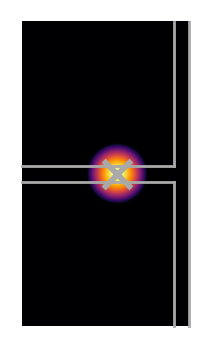

In [7]:
# set up place cells
N = 40
mazeSize = 5.0

# Scale the original TMaze layout to the larger maze
xcen = np.concatenate((
    np.linspace(0.02, 1.00, N) * mazeSize, 
    1.05 * mazeSize * np.ones(N), # 1.05 * mazeSize is the x-coordinate of the rightmost wall of the maze
    1.05 * mazeSize * np.ones(N) # 
))
ycen = np.concatenate((
    np.ones(N) * mazeSize,
    np.linspace(1.03, 2.00, N) * mazeSize, 
    np.linspace(0.97, 0.00, N) * mazeSize
))
centres = np.vstack((xcen, ycen)).T


# set parameters for the MazeAgent class
params = {
           #Maze params 
          'mazeType'            : 'TMaze',  #type of maze, define in getMaze() function
          'stateType'           : 'gaussianThreshold', #feature on which to TD learn (onehot, gaussian, gaussianCS, circles, bump)
          'movementPolicy'      : 'windowsScreensaver',  #movement policy (raudies, random walk, windows screensaver)
          'roomSize'            : mazeSize,          #maze size scaling parameter, metres
          'dt'                  : 0.01,       #simulation time disretisation (defualts to largest )
          'dx'                  : 0.01,       #space discretisation (for plotting, movement is continuous)
          'speedScale'          : 0.16,       #movement speed scale, metres/second
          'rotSpeedScale'       : None,       #rotational speed scale, radians/second
          'initPos'             : None,  #initial position [x0, y0], metres
          'initDir'             : None,      #initial direction, unit vector
          'nCells'              : N,       #how many features to use
          'centres'             : centres,       #array of receptive field positions. Overwrites nCells
          'sigma'               : 1,          #basis cell width scale (irrelevant for onehots)
          'doorsClosed'         : True,       #whether doors are opened or closed in multicompartment maze
          'reorderCells'        : False,       #whether to reorde the cell centres which have been provided
          'firingRateLookUp'    : False,      #use quantised lookup table for firing rates 
          'biasDoorCross'       : False,      #if True, in twoRoom maze door crossings are biased towards
          'biasWallFollow'      : True,       #if True, agent aligns to wall when gets too near.

          #TD params 
          'tau'                 : 4,          #TD decay time, seconds
          'TDdx'                : 0.1,       #rough distance between TD learning updates, metres 
          'alpha'               : 0.01,       #TD learning rate 
          'successorFeatureNorm': 100,        #linear scaling on successor feature definition found to improve learning stability
          'TDreg'               : 0.01,       #L2 regularisation 
          
          #STDP params
          'peakFiringRate'      : 10,          #peak firing rate of a cell (middle of place field,preferred theta phase)
          'tau_STDP_plus'       : 20e-3,      # was 20 pre trace decay time
          'tau_STDP_minus'      : 40e-3,      #was 40 post trace decay time
          'a_STDP'              : -0.4,       # was -0.4, pre-before-post potentiation factor (post-before-pre = 1) 
          'eta'                 : 0.01,       #STDP learning rate
          'baselineFiringRate'  : 0,          #baseline firing rate for cells 
          'use_full_STDP_rule'  : True,      #whether to use full STDP rule     
          'online_mapping'      : 'identity',  #how to map CA3-->CA1 during learning
          'rownorm'             : False,

          #Theta precession params
          'thetaFreq'           : 10,         #theta frequency
          'precessFraction'     : 0.5,        #fraction of 2pi the prefered phase moves through
          'kappa'               : 5,          # von mises spread parameter
          
          #Theta scrambling params (Livi addition)
          'scramble_strength'    : 0.4,        # strength of theta phase scrambling 
          'hf_strength'          : 0.4,        # strength of high frequency jitter added to scrambled theta phase

          # Goal Location
          'goalPos'             : [5.25, 8.0], # 7.5 before. position of goal in metres -> given as array of shape [x, y]
          'goalRadius'          : 0.5,       # radius of goal in metres
          'goalReward'          : 1.0,

}

agent_ST4 = MA.MazeAgent(params)
plotter = MA.Visualiser(agent_ST4)
agent_ST4.toggleDoors(doorsClosed=False)

#plotter.plotMazeStructure() # plot maze structure to check it's correct before starting simulation
plotter.plotReceptiveField(24) # plot receptive field of place cell 5 in the middel of loop
#plotter.plotFeatureCells(centresOnly=True, textlabel=False) # plots centres of the place cells in maze (no heatmap)
#fig, ax = plotter.plotFeatureCells(shufflebeforeplot=False, textlabel=True)
#plotter.plotGoal()

### Make some plots of the Maze, Value Function, Cells
- Value function
- feature cells + maze structure

(<Figure size 400x400 with 1 Axes>, <Axes: >)

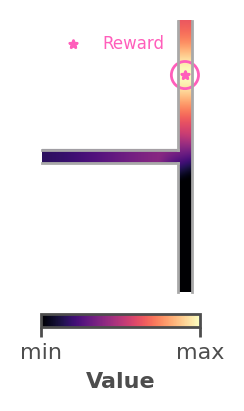

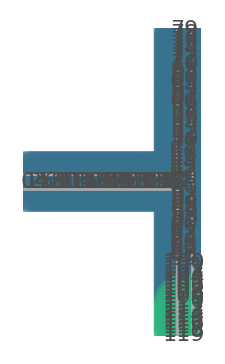

In [8]:
# plot value function
plotter = MA.Visualiser(agent_ST4)

# plot value function
plotter.valueFunctionHeatMap(fig=None, ax=None, smoothing=1, showGoal=True, showCentres=False, save=False)

# plot feature cells
plotter.plotFeatureCells(shufflebeforeplot=False, textlabel=True)

### Pretrain the Agent
- pretrain for 30 minutes  under different conditions
    - TD learning
    - STDP Learning
        - clean theta (10Hz)
        - no theta
        - scrambled theta (0.2; 0.2)
- plot weight matrices for all conditions

**Pretrain Policy**
- Choose left (correct arm) in 90% of cases and right (incorrect) arm in remaining 10% of cases

  0%|          | 0/180000 [00:00<?, ?it/s]

Calculating place and grid cells


(<Figure size 400x400 with 2 Axes>,
 <Axes: title={'center': "SR matrix 'W' after 30min of STDP learning without theta modulation"}>,
 <Axes: >)

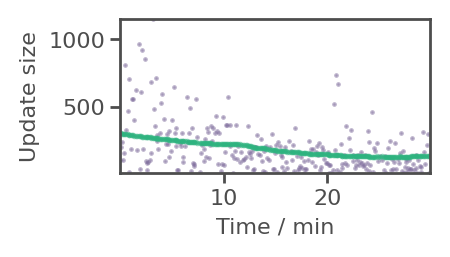

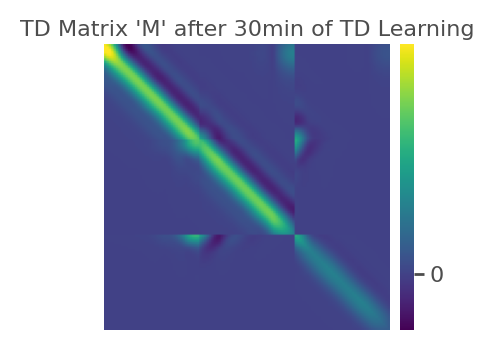

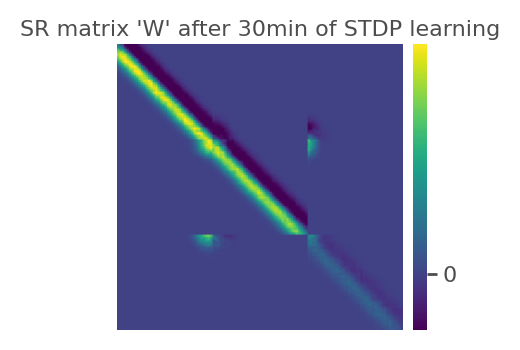

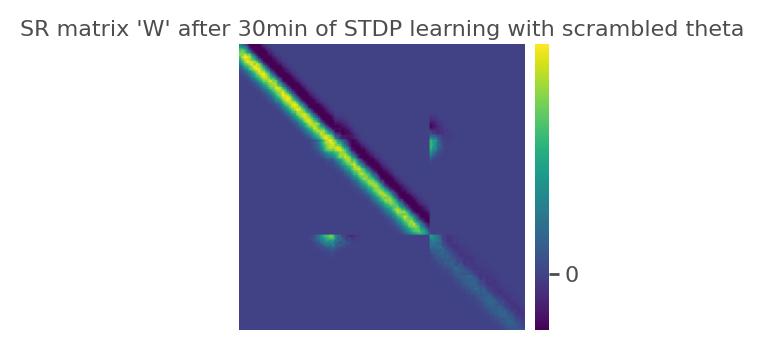

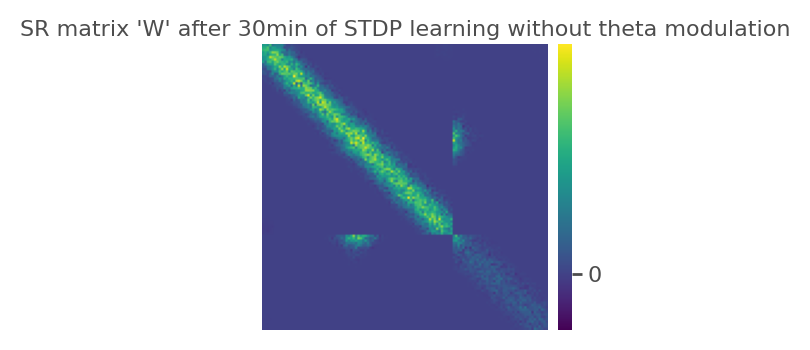

In [9]:
agent_ST4.pos = np.array([0, mazeSize]) # start at the stem center in the scaled T maze
agent_ST4.dir = np.array([1,0]) # start facing right at the start of the stem
agent_ST4.runRat(trainTime=30, STDPLearn=True, TDSRLearn=True, saveEvery=0.5)

# Plot Trajectory for control
plotter = MA.Visualiser(agent_ST4)
#fig, ax = plotter.plotMazeStructure()
#plottimestart, plottimeend = 0, 1
# plotter.plotTrajectory(fig=fig, ax=ax, starttime=plottimestart, endtime=plottimeend)

# Plot SRs fro control
plotter.plotM(whichM="M", colorbar=True, title="TD Matrix 'M' after 30min of TD Learning", save= False) 
plotter.plotM(whichM="W", colorbar=True, title="SR matrix 'W' after 30min of STDP learning", save=False)
# Plot scrambled
plotter.plotM(whichM="W_scrambled", colorbar=True, title="SR matrix 'W' after 30min of STDP learning with scrambled theta", save=False) 
# Plot no_theta
plotter.plotM(whichM="W_notheta", colorbar=True, title="SR matrix 'W' after 30min of STDP learning without theta modulation", save=False)


### Decision Task with Pretrained Agent - 0.4 SCRAMBLED THETA

Running seed 0...
Timeout: 90.0s
dt: 0.01s
Steps: 9000
Expected final elapsed: 90.0s
Epsilon threshold: 89.999999999


  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/9500 [00:00<?, ?it/s]

/Users/liviastein/STDP_Theta-1/STDP-SR_scripts/Task_Setup/HandcraftApproach/MazeAgent_HA.py:1022: RuntimeWarning: overflow encountered in exp
  preTrace        *= np.exp(- timeDiff / self.tau_STDP_plus) #traces for all cells decay...
/Users/liviastein/STDP_Theta-1/STDP-SR_scripts/Task_Setup/HandcraftApproach/MazeAgent_HA.py:1022: RuntimeWarning: invalid value encountered in multiply
  preTrace        *= np.exp(- timeDiff / self.tau_STDP_plus) #traces for all cells decay...
/Users/liviastein/STDP_Theta-1/STDP-SR_scripts/Task_Setup/HandcraftApproach/MazeAgent_HA.py:1023: RuntimeWarning: overflow encountered in exp
  postTrace       *= np.exp(- timeDiff / self.tau_STDP_minus) #traces for all cells decay...
/Users/liviastein/STDP_Theta-1/STDP-SR_scripts/Task_Setup/HandcraftApproach/MazeAgent_HA.py:1023: RuntimeWarning: invalid value encountered in multiply
  postTrace       *= np.exp(- timeDiff / self.tau_STDP_minus) #traces for all cells decay...
/Users/liviastein/STDP_Theta-1/STDP-SR_scr

STDPLearningStep_detailed: replacing non-finite/negative Poisson lambda values with 0.
Episode timed out after 95.0 seconds! Starting new episode!
Calculating place and grid cells


...

Episode timed out after 95.0 seconds! Starting new episode!
Calculating place and grid cells


  0%|          | 0/9500 [00:00<?, ?it/s]

Episode timed out after 95.0 seconds! Starting new episode!
Calculating place and grid cells


  0%|          | 0/9500 [00:00<?, ?it/s]

Episode timed out after 95.0 seconds! Starting new episode!
Calculating place and grid cells
SUMMARY FOR SEED 0 ONLY!:
Seed 0 Summary:
  Total Episodes: 10
  Reached Goal: 1
  Timeouts: 9
  Wrong Arm Choices: 0
  Percentage Correct: 10.00%
  Average Time to Goal: 83.05999999992446
SUMMARY FOR SEED 2 ONLY!:
Seed 2 Summary:
  Total Episodes: 10
  Reached Goal: 0
  Timeouts: 10
  Wrong Arm Choices: 0
  Percentage Correct: 0.00%
  Average Time to Goal: nan
SUMMARY FOR SEED 4 ONLY!:
Seed 4 Summary:
  Total Episodes: 10
  Reached Goal: 1
  Timeouts: 9
  Wrong Arm Choices: 0
  Percentage Correct: 10.00%
  Average Time to Goal: 84.46999999992323
SUMMARY FOR SEED 6 ONLY!:
Seed 6 Summary:
  Total Episodes: 10
  Reached Goal: 1
  Timeouts: 9
  Wrong Arm Choices: 0
  Percentage Correct: 10.00%
  Average Time to Goal: 64.82999999994104
SUMMARY FOR SEED 42 ONLY!:
Seed 42 Summary:
  Total Episodes: 10
  Reached Goal: 0
  Timeouts: 10
  Wrong Arm Choices: 0
  Percentage Correct: 0.00%
  Average Time t

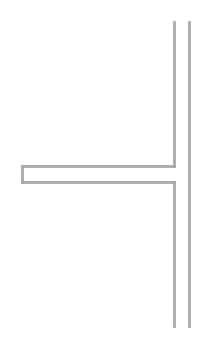

In [10]:
# adapt maze and close off open stem
if agent_ST4.mazeType == "TMaze":
    rs = agent_ST4.roomSize
    corridor_half_width = 0.05 * rs
    agent_ST4.walls['CloseStem'] = np.array([[[0.0, rs-corridor_half_width], [0.0, rs+corridor_half_width]]])
    agent_ST4.mazeState['walls'] = agent_ST4.walls.copy()
    agent_ST4.toggleDoors(doorsClosed=False)
    agent_ST4.discreteStates = agent_ST4.positionArray_to_stateArray(agent_ST4.discreteCoords, stateType= agent_ST4.stateType)
    snapshot = pd.DataFrame({'t': [agent_ST4.t], 'M': [agent_ST4.M.copy()], 'W': [agent_ST4.W.copy()], 'W_notheta':[agent_ST4.W_notheta.copy()], 'W_scrambled':[agent_ST4.W_scrambled.copy()], 'mazeState':[agent_ST4.mazeState]})
    agent_ST4.snapshots = pd.concat([agent_ST4.snapshots, snapshot], ignore_index=True)

# check if maze is changed correctly
plotter = MA.Visualiser(agent_ST4)
plotter.plotMazeStructure()

# run a number of task episodes with pretrained agent (agent_ST4) for each random seed in the list defined earlier, and save results for each seed in a dictionary
results = {}
for seed in random_seeds:
    print(f"Running seed {seed}...")
    np.random.seed(seed); random.seed(seed)

    # save results for seed
    results[seed] = {'episode_logs': [], "episodes": [], "params": params} # to store outcome of each episode for this seed, which we will later use to summarise performance across seeds

    # snapshot agent baseline state 
    base_history_len = len(agent_ST4.history)
    base_snap_len = len(agent_ST4.snapshots)
    baseline_t = agent_ST4.t

    #baseline_theta = getattr(agent_ST4, "thetaPhase", 0.0)
    #baseline_theta_scrambled = getattr(agent_ST4, "thetaPhase_scrambled", 0.0)
    #baseline_spikedata = copy.deepcopy(getattr(agent_ST4, "spikedata", {}))
    #baseline_spikedata_by_condition = copy.deepcopy(getattr(agent_ST4, "spikedata_by_condition", {}))
    #baseline_decoded = copy.deepcopy(getattr(agent_ST4, "decoded_dir_history", []))
    baseline_runID = agent_ST4.runID

    M_before = agent_ST4.M.copy()
    W_before = agent_ST4.W.copy()
    W_notheta_before = agent_ST4.W_notheta.copy()
    W_scrambled_before = agent_ST4.W_scrambled.copy()

    # reset episode-local state (clean start, keep weights)
    agent_ST4.pos = np.array([0.2, mazeSize])            # or [0, mazeSize] per your convention
    agent_ST4.dir = np.array([1.0, 0.0])
    agent_ST4.speed = agent_ST4.speedScale
    agent_ST4.t = 0.0
    agent_ST4.thetaPhase = 0.0
    agent_ST4.thetaPhase_scrambled = 0.0
    agent_ST4.thetaPhase_scrambled_history = []
    agent_ST4.thetaPhase_scrambled_time_history = []

    agent_ST4.spikedata = {'CA3': {'times': [], 'ids': []}, 'CA1': {'times': [], 'ids': []}}
    agent_ST4.spikedata_by_condition = {
        'theta': {'CA1': {'times': [], 'ids': []}, 'CA3': {'times': [], 'ids': []}},
        'notheta': {'CA1': {'times': [], 'ids': []}, 'CA3': {'times': [], 'ids': []}},
        'scrambled': {'CA1': {'times': [], 'ids': []}, 'CA3': {'times': [], 'ids': []}}
    }
    agent_ST4.decoded_dir_history = []
    agent_ST4.reachedGoal = False
    agent_ST4.goalReachedTime = 0.0
    agent_ST4.lastTurnUpdate = -1
    agent_ST4.randomTurnSpeed = 0
    agent_ST4.doorPassage = False
    agent_ST4.doorPassageTime = 0.0

    # Diagnostic: check timeout condition behavior
    timeout_test = 90.0
    dt_test = agent_ST4.dt
    steps_test = int(timeout_test / dt_test)
    print(f"Timeout: {timeout_test}s")
    print(f"dt: {dt_test}s")
    print(f"Steps: {steps_test}")
    print(f"Expected final elapsed: {steps_test * dt_test}s")
    print(f"Epsilon threshold: {timeout_test - 1e-9}")


    # run decision task episodes
    episodes = 10
    for ep in tqdm(range(episodes)):
        history_start = len(agent_ST4.history)
        snapshot_start = len(agent_ST4.snapshots)
        t_start = agent_ST4.t
        runid_start = agent_ST4.runID

        outcome = agent_ST4.TaskEpisode(saveEvery=0.5, 
                                        TDSRLearn=True, 
                                        STDPLearn=True, 
                                        condition = 'scrambled', 
                                        phase_threshold = 1.4*np.pi, 
                                        t_window =None,
                                        updateSTDPWeights = False,
                                        maxTurnAngle = True,
                                        maxAngle = 50.0,
                                        timeout = 95.0)
        # store outcome of episode
        history_end = len(agent_ST4.history)
        snapshot_end = len(agent_ST4.snapshots)
        t_end = agent_ST4.t
        runid_end = agent_ST4.runID

        assert runid_end == runid_start + 1, (
              f"runID mismatch at seed={seed}, ep={ep}: "
              f"start={runid_start}, end={runid_end}"
        )

        # metadata row for this episode
        metadata = {
            'seed': seed,
            'episode': ep,
            'runID_start': runid_start,
            'runID_end': runid_end,
            't_start': t_start,
            't_end': t_end,
            "duration": t_end - t_start,
            "history_start": history_start,
            "history_end": history_end,
            "snapshot_start": snapshot_start,
            "snapshot_end": snapshot_end,
            "outcome": outcome
        }
        results[seed]['episode_logs'].append(metadata)

        # payload data for this episode
        payload = {"history": agent_ST4.history.iloc[history_start:history_end].reset_index(drop=True),
                     "snapshots": agent_ST4.snapshots.iloc[snapshot_start:snapshot_end].reset_index(drop=True),
                     "spikedata": copy.deepcopy(agent_ST4.spikedata),
                     "spikedata_by_condition": copy.deepcopy(agent_ST4.spikedata_by_condition),
                     "final_weights": {
                          'M': agent_ST4.M.copy(),
                          'W': agent_ST4.W.copy(),
                          'W_notheta': agent_ST4.W_notheta.copy(),
                          'W_scrambled': agent_ST4.W_scrambled.copy()
                     }
          }       
        results[seed]['episodes'].append(payload)

    # save final outcome/weights if desired
    results[seed]["final_weights_pre_restore"] = {
        "M": agent_ST4.M.copy(), "W": agent_ST4.W.copy(),
        "W_notheta": agent_ST4.W_notheta.copy(), "W_scrambled": agent_ST4.W_scrambled.copy()
    }

    # 6) restore agent to baseline (clean reset) so next seed starts from same pretrained state
    agent_ST4.M = M_before
    agent_ST4.W = W_before
    agent_ST4.W_notheta = W_notheta_before
    agent_ST4.W_scrambled = W_scrambled_before
    agent_ST4.history = agent_ST4.history.iloc[:base_history_len].reset_index(drop=True)
    agent_ST4.snapshots = agent_ST4.snapshots.iloc[:base_snap_len].reset_index(drop=True)
    agent_ST4.t = baseline_t
    agent_ST4.runID = baseline_runID

# restore original maze -> open stem again
if 'CloseStem' in getattr(agent_ST4, 'walls', {}):
                del agent_ST4.walls['CloseStem'] # remove wall closing stem after decision task is done, so agent can explore whole maze again
                agent_ST4.mazeState['walls'] = agent_ST4.walls.copy()
                agent_ST4.toggleDoors(doorsClosed = False) # make sure right arm is open again
                agent_ST4.discreteStates = agent_ST4.positionArray_to_stateArray(agent_ST4.discreteCoords, stateType=agent_ST4.stateType) # recalculate discrete states to account for removed wall 
            
# summarise performance results per seed episodes and across seeds: i.e. get reward count, total reward, number of timeouts, number of wrong arm choices, and average time to reach goal.
summary = []
for seed, data in results.items():
    episode_logs = data['episode_logs']
    episodes = data['episodes']

    # summarise for one seed
    outcome_rows = []
    for log in episode_logs:
        outcome = log['outcome']
        if outcome['reward_count'] > 0:
            label = 'reached_goal'
        elif outcome['wrong_arm_count'] > 0:
            label = 'wrong_arm'
        elif outcome['timeout_count'] > 0:
            label = 'timeout'
        else:
            label = 'unknown'
        outcome_rows.append({'label': label, 'duration': log['duration']})

    outcome_df = pd.DataFrame(outcome_rows)
    seed_summary = {
        'seed': seed,
        'total_episodes': len(episode_logs),
        'reached_goal': int((outcome_df['label'] == 'reached_goal').sum()),
        'timeouts': int((outcome_df['label'] == 'timeout').sum()),
        'wrong_arm': int((outcome_df['label'] == 'wrong_arm').sum()),
        'percentage_correct': float((outcome_df['label'] == 'reached_goal').sum()) / len(outcome_df) if len(outcome_df) > 0 else np.nan,
        'average_time_to_goal': float(outcome_df.loc[outcome_df['label'] == 'reached_goal', 'duration'].mean()) if (outcome_df['label'] == 'reached_goal').any() else np.nan
    }
    summary.append(seed_summary)
    # print summary for this seed
    print(f"SUMMARY FOR SEED {seed} ONLY!:")
    print(f"Seed {seed} Summary:")
    print(f"  Total Episodes: {seed_summary['total_episodes']}")
    print(f"  Reached Goal: {seed_summary['reached_goal']}")
    print(f"  Timeouts: {seed_summary['timeouts']}")
    print(f"  Wrong Arm Choices: {seed_summary['wrong_arm']}")
    print(f"  Percentage Correct: {seed_summary['percentage_correct']:.2%}")
    print(f"  Average Time to Goal: {seed_summary['average_time_to_goal']}")
    print("========================================")

# summary across seeds
total_episodes = sum(s['total_episodes'] for s in summary)
total_reached_goal = sum(s['reached_goal'] for s in summary)
total_timeouts = sum(s['timeouts'] for s in summary)
total_wrong_arm = sum(s['wrong_arm'] for s in summary)
goal_times = [s['average_time_to_goal'] for s in summary if not np.isnan(s['average_time_to_goal'])]
average_time_to_goal = float(np.mean(goal_times)) if len(goal_times) > 0 else np.nan
print(f"Overall Summary Across Seeds {random_seeds}:")
print(f"  Total Episodes: {total_episodes}")
print(f"  Reached Goal: {total_reached_goal}")
print(f"  Timeouts: {total_timeouts}")
print(f"  Wrong Arm Choices: {total_wrong_arm}")
print(f"  Average Time to Goal: {average_time_to_goal}")
print(f"  Percentage Correct: {total_reached_goal / total_episodes:.2%}" if total_episodes > 0 else np.nan)
print("========================================")


Overall Summary Across Seeds [0, 2, 4, 6, 42]:
  Total Episodes: 50
  Reached Goal: 2
  Timeouts: 48
  Wrong Arm Choices: 0
  Average Time to Goal: 67.76499999996892
  Percentage Correct: 4.00%
========================================

### Movement Heatmap

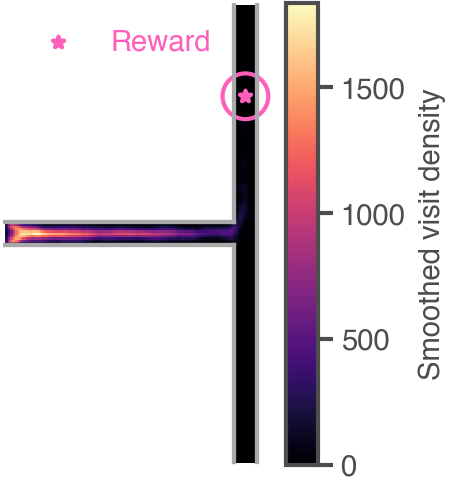

In [12]:
all_positions = []
for seed, data in results.items():
    for episode_payload in data['episodes']:
        history = episode_payload['history']
        if 'pos' in history.columns and len(history) > 0:
            pos = np.vstack(history['pos'].to_numpy())
            all_positions.append(pos)

all_positions = np.vstack(all_positions)

from mpl_toolkits.axes_grid1 import make_axes_locatable
#from scipy.ndimage import gaussian_filter
import numpy as np
plt.style.use('/Users/liviastein/STDP_Theta-1/ResultPipelines/plot_style.mplstyle')

rs = agent_ST4.roomSize
hw = 0.05 * rs
arm_w = 2 * hw

# draw maze and record extents
fig, ax = plotter.plotMazeStructure(fig=None, ax=None)
xlim = ax.get_xlim()
ylim = ax.get_ylim()
ax.set_aspect('equal') 

#dx = dy = 0.01
#xedges = np.arange(xlim[0], xlim[1] + dx, dx)
#yedges = np.arange(ylim[0], 9.99 + dy, dy)
# compute 2D histogram over full maze extents
H, xedges, yedges = np.histogram2d(
    all_positions[:,0], all_positions[:,1],
    bins=[110, 200], range=[[xlim[0], xlim[1]], [ylim[0], 9.99]]
)

# mask values outside of the maze walls by creating a mask
xc = 0.5 * (xedges[:-1] + xedges[1:])
yc = 0.5 * (yedges[:-1] + yedges[1:])
X, Y = np.meshgrid(xc, yc, indexing="ij") # create grid of coordinates for histogram bins

# define mask for points inside the maze structure (i.e. within walls)
inside = (
    ((X >= 0) & (X <= rs) & (Y >= rs - hw) & (Y <= rs + hw)) |
    ((X >= rs) & (X <= rs + arm_w) & (Y >= 0) & (Y <= 2 * rs))
)

H_masked = np.ma.array(H, mask=~inside)
from scipy.ndimage import gaussian_filter

H_smooth = gaussian_filter(H, sigma=1)
H_masked = np.ma.array(H_smooth, mask=(~inside))

cmap = plt.cm.magma.copy() # copy the colormap
cmap.set_bad(alpha=0) # make masked values transparent

# show with imshow (transpose H so axes match), keep extent = full maze
#extent = agent_CT.extent
extent = [xedges[0], xedges[-1], yedges[0], yedges[-1]]
#im = ax.imshow(H_smooth.T, origin='lower', extent=extent, cmap='magma', alpha=1, zorder=0, aspect='auto')
im = ax.imshow(H_masked.T, origin='lower', extent=extent, cmap='magma', alpha=1, zorder=0, aspect='equal', interpolation='nearest')

# thin colorbar matching axis height
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="12%", pad=0.05)
fig.colorbar(im, cax=cax, label='Smoothed visit density')

# restore exact view and aspect, and redraw maze lines on top
ax.set_xlim(xlim); ax.set_ylim(ylim)
ax.set_aspect('equal') 
plotter.plotMazeStructure(fig=fig, ax=ax)   # draws lines on top
plotter.plotGoal(fig=fig, ax=ax)   # draw goal on top of maze structure

plt.savefig("/Users/liviastein/STDP_Theta-1/Final_Figures/TrajectoryHM_ST4.pdf", transparent=True)
#plt.tight_layout()
plt.show()

### Performance Plots

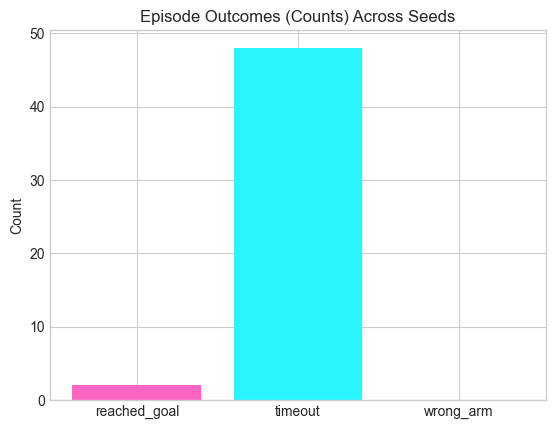

In [10]:
plt.close('all')
plt.rcdefaults()
# bar plot with outcomes across seeds as counts
# use specific style for plot
plt.style.use('seaborn-v0_8-whitegrid')
# define own color palette with colour keys
Livi_palette = ['#ff66c4', '#2AF5FF', '#531CB3']

summary_df = pd.DataFrame(summary)
labels = ['reached_goal', 'timeout', 'wrong_arm']
counts = [
    int(summary_df['reached_goal'].sum()),
    int(summary_df['timeouts'].sum()),
    int(summary_df['wrong_arm'].sum())
 ]
x = np.arange(len(labels))

fig, ax = plt.subplots()
bars = ax.bar(x, counts, color= Livi_palette)
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel('Count')
ax.set_title('Episode Outcomes (Counts) Across Seeds')

plt.show()

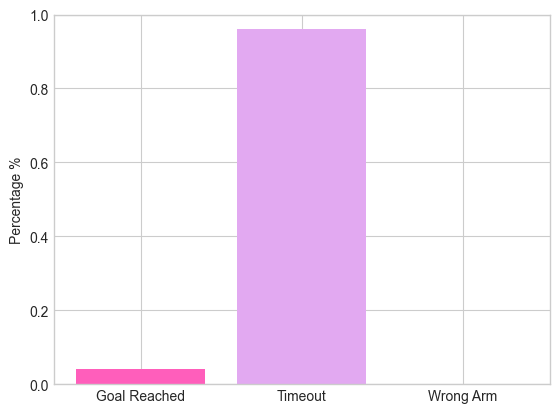

In [20]:
# bar plot with outcomes across seeds as percentages: e.g. timout/total episodes etc
# use specific style for plot
plt.style.use('seaborn-v0_8-whitegrid')
# define own color palette with colour keys
#Livi_palette1 = ['#ff66c4', '#2AF5FF', '#531CB3']
Livi_palette = {
    "türkis": '#66dfd8',
    "lBlue": '#1097d3',
    "dViolet": '#5e17eb',
    "lpurple": '#8c52ff',
    "altRosa": '#cb6ce6',
    "lRosa": '#e2a9f1',
    "pink": '#ff5ebb'
}

#summary_df = pd.DataFrame(summary)
labels = ['Goal Reached', 'Timeout', 'Wrong Arm']
total_episodes = sum(s['total_episodes'] for s in summary)
reached = sum(s['reached_goal'] for s in summary)
timeouts = sum(s['timeouts'] for s in summary)
wrong_arm = sum(s['wrong_arm'] for s in summary)
percentages = [reached/total_episodes, timeouts/total_episodes, wrong_arm/total_episodes] if total_episodes>0 else [np.nan]*3

#total_episodes = summary_df['total_episodes'].sum()
#percentages = [
    #float(summary_df['reached_goal'].sum()) / total_episodes if total_episodes > 0 else np.nan,
    #float(summary_df['timeouts'].sum()) / total_episodes if total_episodes > 0 else np.nan,
    #float(summary_df['wrong_arm'].sum()) / total_episodes if total_episodes > 0 else np.nan
#]
x = np.arange(len(labels))
fig, ax = plt.subplots()
bars = ax.bar(x, percentages, color= [Livi_palette['pink'], Livi_palette['lRosa'], Livi_palette['altRosa']])
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel('Percentage %')
# set limit for y axis to 0-100%
ax.set_ylim(0, 1)
#plt.suptitle('Episode Outcomes (Percentages) Across 50 Seeds', fontsize=14, fontweight='bold')
# add subtitle with theta condition and number of episodes in italics
#ax.set_title(f"STDP Learning with Clean Theta - {total_episodes} Episodes per Seed", fontsize=10, fontstyle='italic', loc='center')

plt.show()
 

per-seed successful counts: {0: 1, 2: 1, 4: 0, 6: 0, 42: 0}
sum of per-seed successful counts: 2
summary total_reached_goal (from seed summaries): 2


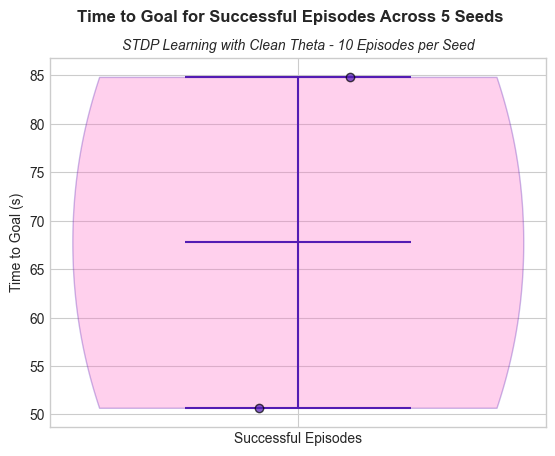

In [18]:
plt.close('all')
plt.rcdefaults()
# create violin plot of time to goal for successful episodes across seeds
plt.style.use('seaborn-v0_8-whitegrid')
# define own color palette with colour keys
Livi_palette = ['#ff66c4', '#2AF5FF', '#531CB3']
total_episodes = sum(s['total_episodes'] for s in summary)
# debug: per-seed successful counts (from `results`)
success_counts = {
    seed: sum(1 for log in data['episode_logs'] if log.get('outcome', {}).get('reward_count', 0) > 0)
    for seed, data in results.items()
}
print('per-seed successful counts:', success_counts)
print('sum of per-seed successful counts:', sum(success_counts.values()))
print('summary total_reached_goal (from seed summaries):', sum(s['reached_goal'] for s in summary))

# collect per-episode durations for successful episodes (reward_count > 0)
successful_times = [
    log['duration']
    for seed, data in results.items()
    for log in data['episode_logs']
    if log.get('outcome', {}).get('reward_count', 0) > 0
]

# convert to numpy array for plotting (optional)
successful_times = np.array(successful_times)

fig, ax = plt.subplots()
ax.violinplot(successful_times, showmeans=True, showmedians=False, showextrema=True)
# set face colour and edge colour of the violin plot
for body in ax.collections:
    try:
        body.set_facecolor(Livi_palette[0])
        body.set_edgecolor(Livi_palette[2])
    except Exception:
        pass

# scatter actual data points from episodes on top of violin plot and spread them a bit horizontally
x = np.random.normal(1, 0.04, size=len(successful_times))  # spread around x=1 with small random noise
ax.scatter(x, successful_times, color=Livi_palette[2], alpha=0.7, edgecolor='k', zorder=2)

# set y-limits sensibly
if len(successful_times) > 0:
    ymin = max(0, successful_times.min() - 2)
    ymax = successful_times.max() + 2
    ax.set_ylim(ymin, ymax)
else:
    ax.set_ylim(0, 1)

ax.set_xticks([1])
ax.set_xticklabels(['Successful Episodes'])
ax.set_ylabel('Time to Goal (s)')
plt.suptitle('Time to Goal for Successful Episodes Across 5 Seeds', fontsize=12, fontweight='bold')
ax.set_title(f"STDP Learning with Clean Theta - {10} Episodes per Seed", fontsize=10, fontstyle='italic', loc='center')
plt.show()

### Summarise Results in Table and Export

In [13]:
from pathlib import Path

theta_condition = "ScrTheta_0.4"  # change this in each notebook
out_dir = Path("/Users/liviastein/STDP_Theta-1/ResultPipelines/summary_tables_K5")
out_dir.mkdir(parents=True, exist_ok=True)

rows = []
for seed, data in results.items():
    for log in data["episode_logs"]:
        outcome = log.get("outcome", {})
        if outcome.get("reward_count", 0) > 0:
            label = "reached_goal"
        elif outcome.get("wrong_arm_count", 0) > 0:
            label = "wrong_arm"
        elif outcome.get("timeout_count", 0) > 0:
            label = "timeout"
        else:
            label = "unknown"

        rows.append({
            "theta_condition": theta_condition,
            "seed": seed,
            "episode": log.get("episode"),
            "label": label,
            "duration": log.get("duration", np.nan),
            "reward_count": outcome.get("reward_count", 0),
            "wrong_arm_count": outcome.get("wrong_arm_count", 0),
            "timeout_count": outcome.get("timeout_count", 0),
        })

episode_table = pd.DataFrame(rows)

seed_summary_table = (
    episode_table.groupby(["theta_condition", "seed"], as_index=False)
    .agg(
        total_episodes=("episode", "count"),
        reached_goal=("label", lambda s: int((s == "reached_goal").sum())),
        wrong_arm=("label", lambda s: int((s == "wrong_arm").sum())),
        timeouts=("label", lambda s: int((s == "timeout").sum())),
        percentage_correct=("label", lambda s: float((s == "reached_goal").sum()) / len(s) if len(s) > 0 else np.nan),
        average_time_to_goal=("duration", lambda s: float(s[episode_table.loc[s.index, "label"] == "reached_goal"].mean())
                              if (episode_table.loc[s.index, "label"] == "reached_goal").any() else np.nan),
    )
)

episode_table.to_csv(out_dir / f"{theta_condition}_episode_table.csv", index=False)
seed_summary_table.to_csv(out_dir / f"{theta_condition}_seed_summary_table.csv", index=False)

print(episode_table.head())
print("===============================")
print(seed_summary_table)

  theta_condition  seed  episode    label  duration  reward_count  \
0    ScrTheta_0.4     0        0  timeout     90.00             0   
1    ScrTheta_0.4     0        1  timeout     90.01             0   
2    ScrTheta_0.4     0        2  timeout     90.01             0   
3    ScrTheta_0.4     0        3  timeout     90.01             0   
4    ScrTheta_0.4     0        4  timeout     90.01             0   

   wrong_arm_count  timeout_count  
0                0              1  
1                0              1  
2                0              1  
3                0              1  
4                0              1  
  theta_condition  seed  total_episodes  reached_goal  wrong_arm  timeouts  \
0    ScrTheta_0.4     0              10             1          0         9   
1    ScrTheta_0.4     2              10             0          0        10   
2    ScrTheta_0.4     4              10             1          0         9   
3    ScrTheta_0.4     6              10             1    